##Exemplo de CNN: Reconhecimento de Dígitos (MNIST) com CNN 2D

Vamos treinar uma CNN 2D tradicional para reconhecimento de dígitos manuscritos usando o famoso dataset **MNIST**.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Carregar e Pré-processar o Dataset MNIST

In [ ]:
(imagens_treino_mnist, rotulos_treino_mnist), (imagens_teste_mnist, rotulos_teste_mnist) = tf.keras.datasets.mnist.load_data()

# Normalizar as imagens para [0, 1] e redimensionar para (28, 28, 1) para a CNN 2D
imagens_treino_mnist = imagens_treino_mnist.astype('float32') / 255.0
imagens_teste_mnist = imagens_teste_mnist.astype('float32') / 255.0
imagens_treino_mnist = np.expand_dims(imagens_treino_mnist, -1)
imagens_teste_mnist = np.expand_dims(imagens_teste_mnist, -1)

# As imagens MNIST são 28x28 em tons de cinza (1 canal)
TAMANHO_IMAGEM_MNIST = 28
NUM_CLASSES_MNIST = 10 # 0-9 dígitos

# Converter numpy arrays para tf.data.Dataset
dataset_treino_tf_mnist = tf.data.Dataset.from_tensor_slices((imagens_treino_mnist, rotulos_treino_mnist))
dataset_teste_tf_mnist = tf.data.Dataset.from_tensor_slices((imagens_teste_mnist, rotulos_teste_mnist))

TAMANHO_LOTE_MNIST = 128 # Tamanho do lote para MNIST

# # Adicionar buffer e batching
dataset_treino_tf_mnist = dataset_treino_tf_mnist.shuffle(10000).batch(TAMANHO_LOTE_MNIST).prefetch(tf.data.AUTOTUNE)
dataset_teste_tf_mnist = dataset_teste_tf_mnist.batch(TAMANHO_LOTE_MNIST).prefetch(tf.data.AUTOTUNE)

### Visualizar Imagens do MNIST

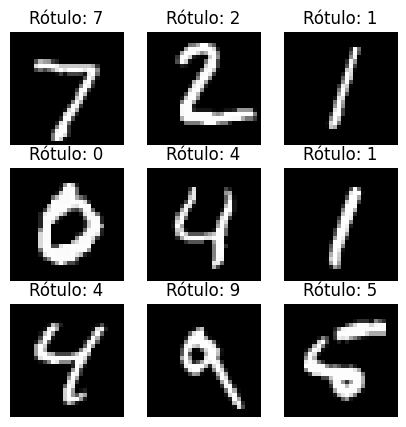

In [3]:
plt.figure(figsize=(5, 5))
for i, (imagem, rotulo) in enumerate(dataset_teste_tf_mnist.unbatch().take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(imagem.numpy().squeeze(), cmap='gray')
    plt.title(f"Rótulo: {rotulo.numpy()}")
    plt.axis("off")
plt.show()

### Construir o Modelo CNN 2D

In [ ]:
modelo_mnist = keras.Sequential([
    keras.Input(shape=(TAMANHO_IMAGEM_MNIST, TAMANHO_IMAGEM_MNIST, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES_MNIST, activation="softmax")
])

modelo_mnist.summary()

### Compilar e Treinar o Modelo CNN 2D

In [ ]:
modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCAS_MNIST = 10

historico_mnist = modelo_mnist.fit(
    dataset_treino_tf_mnist,
    validation_data=dataset_teste_tf_mnist,
    epochs=EPOCAS_MNIST
)

In [ ]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.plot(historico_mnist.history['accuracy'], 'r--', label='Acurácia de Treino')
plt.plot(historico_mnist.history['val_accuracy'],'b-.', label='Acurácia de Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(historico_mnist.history['loss'],'r--', label='Perda de Treino')
plt.plot(historico_mnist.history['val_loss'],'b-.', label='Perda de Validação')
plt.title('Perda')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Avaliar o Modelo CNN 2D

In [ ]:
perda_mnist, acuracia_mnist = modelo_mnist.evaluate(dataset_teste_tf_mnist)
print(f"Perda no conjunto de teste MNIST: {perda_mnist:.4f}")
print(f"Acurácia no conjunto de teste MNIST: {acuracia_mnist:.4f}")

### Salvar o Modelo CNN 2D

In [12]:
caminho_salvar_modelo_mnist = 'cnn2d_mnist_modelo_digito.h5'
modelo_mnist.save(caminho_salvar_modelo_mnist)
modelo_mnist.save('cnn2d_mnist_modelo_digito.keras')
modelo_mnist.save_weights('cnn2d_mnist_modelo_digito_pesos.weights.h5')

pd.DataFrame(historico_mnist.history).to_csv('cnn2d_mnist_historico_modelo.csv', index=False)